In [107]:
import _sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

from fregit_unit_predict.model_evalution import evaluate_model

In [108]:
conn = _sqlite3.connect('D:\invoice intelligence\data\inventory.db')

In [109]:
purchase_agg = pd.read_sql_query("""
select
p.PONumber,
count(distinct p.Brand) as total_brands,
sum(p.Quantity) as total_items_quantity,
sum(p.Dollars) as total_item_dollars,
avg(julianday(p.ReceivingDate) - julianday(p.PODate)) as avg_received_delay

from purchases p
group by p.PONumber
""", conn)

In [110]:
pd.read_sql_query("""
select
vi.Quantity as invoice_quantity,
vi.Dollars as invoice_dollars,
vi.Freight,
(julianday(vi.InvoiceDate) - julianday(vi.PODate)) as days_po_to_invoice,
(julianday(vi.PayDate) - julianday(vi.PODate)) as days_to_pay
from vendor_invoice vi
""", conn)

,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay
0,6,214.26,3.47,14.0,57.0
1,15,140.55,8.57,16.0,61.0
2,5,106.60,4.61,16.0,54.0
3,10100,137483.78,2935.20,23.0,47.0
4,1935,15527.25,429.20,14.0,50.0
...,...,...,...,...,...
5538,90,1563.00,8.60,16.0,51.0
5539,4617,37300.48,186.50,18.0,57.0
5540,9848,202815.78,932.95,11.0,44.0
5541,24747,149007.56,819.54,14.0,50.0


In [111]:
df = pd.read_sql_query("""
WITH purchases_agg AS (
    SELECT
        p.PONumber,
        COUNT(DISTINCT p.Brand) AS total_brands,
        SUM(p.Quantity) AS total_items_quantity,
        SUM(p.Dollars) AS total_item_dollars,
        AVG(julianday(p.ReceivingDate) - julianday(p.PODate)) AS avg_received_delay
    FROM purchases p
    GROUP BY p.PONumber
)

SELECT
    vi.PONumber,
    vi.Quantity AS invoice_quantity,
    vi.Dollars AS invoice_dollars,
    vi.Freight,
    (julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice,
    (julianday(vi.PayDate) - julianday(vi.PODate)) AS days_to_pay,
    pa.total_brands,
    pa.total_items_quantity,
    pa.total_item_dollars,
    pa.avg_received_delay
FROM vendor_invoice vi
LEFT JOIN purchases_agg pa
ON vi.PONumber = pa.PONumber
""", conn)

In [112]:
df.isnull().sum()

PONumber                0
invoice_quantity        0
invoice_dollars         0
Freight                 0
days_po_to_invoice      0
days_to_pay             0
total_brands            0
total_items_quantity    0
total_item_dollars      0
avg_received_delay      0
dtype: int64

In [113]:
df.dtypes

PONumber                  int64
invoice_quantity          int64
invoice_dollars         float64
Freight                 float64
days_po_to_invoice      float64
days_to_pay             float64
total_brands              int64
total_items_quantity      int64
total_item_dollars      float64
avg_received_delay      float64
dtype: object

In [114]:
def create_invoice_risk_label(row):
    #invoice total mismatch with item-level total
    if (abs(row['invoice_dollars'] - row['total_item_dollars']) > 5):
        return 1
    #Abnormally high receiving delay
    if row['avg_received_delay'] > 10:
        return 1
    return 0
df['flag_invoice'] = df.apply(create_invoice_risk_label, axis=1)
df['flag_invoice'].value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

<Axes: xlabel='flag_invoice'>

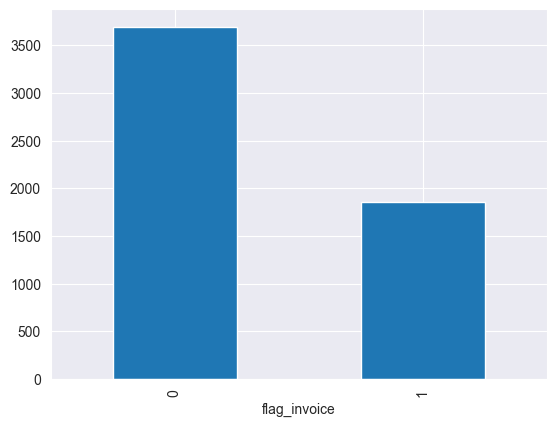

In [115]:
df['flag_invoice'].value_counts().plot(kind='bar')

In [116]:
df.corr()

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_items_quantity,total_item_dollars,avg_received_delay,flag_invoice
PONumber,1.000000,0.049230,0.058917,0.043617,-0.002234,0.012045,0.013423,0.049442,0.059221,-0.042362,0.564946
invoice_quantity,0.049230,1.000000,0.963831,0.946550,0.000526,0.023920,0.566394,0.706117,0.668171,0.000519,0.032783
invoice_dollars,0.058917,0.963831,1.000000,0.985141,0.001610,0.028114,0.536952,0.667666,0.679537,0.004694,0.037994
Freight,0.043617,0.946550,0.985141,1.000000,0.003265,0.028897,0.536381,0.656616,0.670768,0.015645,0.037759
days_po_to_invoice,-0.002234,0.000526,0.001610,0.003265,1.000000,0.174757,0.009519,0.005543,0.007931,0.515538,0.183115
days_to_pay,0.012045,0.023920,0.028114,0.028897,0.174757,1.000000,0.026958,0.020321,0.021047,0.261361,0.098297
total_brands,0.013423,0.566394,0.536952,0.536381,0.009519,0.026958,1.000000,0.783825,0.753092,0.000496,0.008961
total_items_quantity,0.049442,0.706117,0.667666,0.656616,0.005543,0.020321,0.783825,1.000000,0.963831,-0.014016,0.032783
total_item_dollars,0.059221,0.668171,0.679537,0.670768,0.007931,0.021047,0.753092,0.963831,1.000000,-0.014251,0.037994
avg_received_delay,-0.042362,0.000519,0.004694,0.015645,0.515538,0.261361,0.000496,-0.014016,-0.014251,1.000000,0.311667


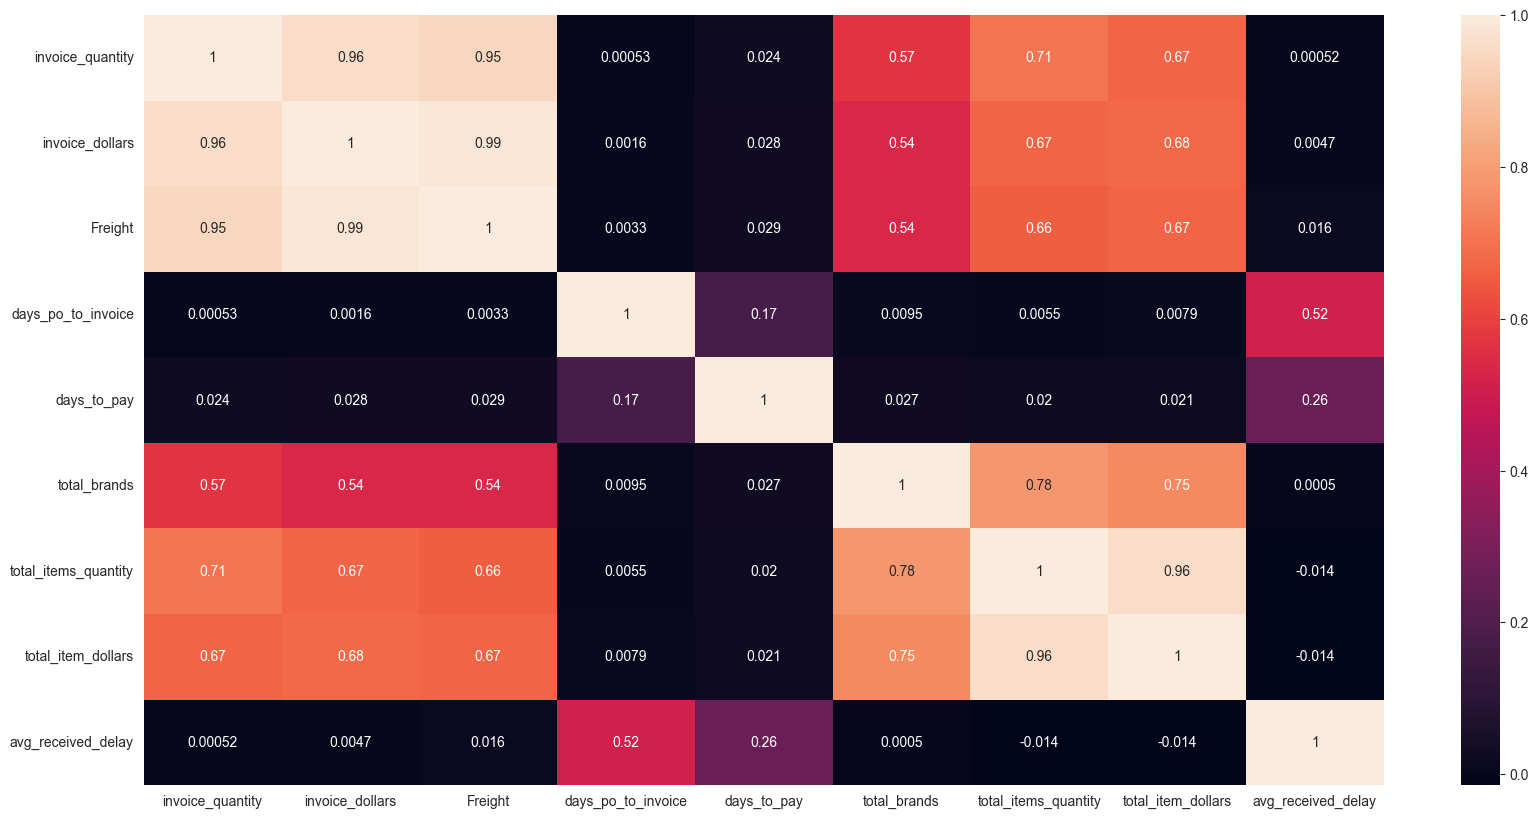

In [117]:
plt.figure(figsize=(20, 10))
sns.heatmap(df.iloc[:,1:-1].corr(), annot=True)
plt.show()

In [118]:
flagged = df[df['flag_invoice'] == 1]
normal = df[df['flag_invoice'] == 0]

In [119]:
significant_features = []
non_significant_features = []
results = []

In [120]:
metrics = ['invoice_quantity', 'invoice_dollars', 'Freight',
           'days_po_to_invoice', 'days_to_pay', 'total_brands', 'total_items_quantity','total_item_dollars', 'avg_received_delay']

In [121]:
from scipy.stats import ttest_ind
for metric in  metrics:
    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()

    t_stat, p_value = ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var=False
    )

    if p_value < 0.05:
        significant_features.append(metric)
        results.append({
            'metric': metric,
            'flagged_mean': flagged_mean.round(2),
            'normal_mean': normal_mean.round(2),
            'p_value': p_value.round(3),
        }
        )
    else:
            non_significant_features.append(metric)

In [122]:
X = df[['invoice_quantity', 'invoice_dollars', 'Freight','total_brands', 'total_items_quantity','days_po_to_invoice','total_item_dollars']]
y = df['flag_invoice']

In [123]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [124]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [125]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [126]:
model1 = LogisticRegression(random_state=42)
model1.fit(X_train_scaled, y_train)

model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train_scaled, y_train)

model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [127]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

models = [
    (model1, 'LogisticRegression'),
    (model2, 'DecisionTree Classifier'),
    (model3, 'RandomForestClassifier')
]

for model, name in models:
    preds = model.predict(X_test_scaled)
    print(f"\n{'='*40}")
    print(f"{name} Performance")
    print(f"{'='*40}")
    print(f"Accuracy : {accuracy_score(y_test, preds):.4f}")
    print(f"Precision: {precision_score(y_test, preds):.4f}")
    print(f"Recall   : {recall_score(y_test, preds):.4f}")
    print(f"F1 Score : {f1_score(y_test, preds):.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, preds, target_names=['Normal', 'Flagged']))
    print(f"Confusion Matrix:\n{confusion_matrix(y_test, preds)}")


LogisticRegression Performance
Accuracy : 0.6583
Precision: 0.5610
Recall   : 0.0599
F1 Score : 0.1082

Classification Report:
              precision    recall  f1-score   support

      Normal       0.66      0.98      0.79       725
     Flagged       0.56      0.06      0.11       384

    accuracy                           0.66      1109
   macro avg       0.61      0.52      0.45      1109
weighted avg       0.63      0.66      0.55      1109

Confusion Matrix:
[[707  18]
 [361  23]]

DecisionTree Classifier Performance
Accuracy : 0.8115
Precision: 0.7358
Recall   : 0.7109
F1 Score : 0.7232

Classification Report:
              precision    recall  f1-score   support

      Normal       0.85      0.86      0.86       725
     Flagged       0.74      0.71      0.72       384

    accuracy                           0.81      1109
   macro avg       0.79      0.79      0.79      1109
weighted avg       0.81      0.81      0.81      1109

Confusion Matrix:
[[627  98]
 [111 273]]

Ra

In [128]:
model3.feature_importances_

array([0.15137936, 0.15124851, 0.14480642, 0.07920458, 0.17669413,
       0.07717963, 0.21948736])

In [129]:
features_importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model3.feature_importances_
}).sort_values(by="importance", ascending=False)

features_importances

,feature,importance
6,total_item_dollars,0.219487
4,total_items_quantity,0.176694
0,invoice_quantity,0.151379
1,invoice_dollars,0.151249
2,Freight,0.144806
3,total_brands,0.079205
5,days_po_to_invoice,0.077180


In [139]:
X = df[['invoice_quantity', 'invoice_dollars', 'Freight', 'total_items_quantity','total_item_dollars']]
y = df['flag_invoice']

In [140]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [141]:
model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, y_train) #i re-train the model3 because if i dont retrain it will expect 7 feature instead of 5

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [142]:
models = [
    (model3, 'RandomForestClassifier')
]

In [143]:
for model, name in models:
    preds = model.predict(X_test_scaled)
    print(f"\n{'=' * 40}")
    print(f"{name} Performance")
    print(f"{'=' * 40}")
    print(f"Accuracy : {accuracy_score(y_test, preds):.4f}")
    print(f"Precision: {precision_score(y_test, preds):.4f}")
    print(f"Recall   : {recall_score(y_test, preds):.4f}")
    print(f"F1 Score : {f1_score(y_test, preds):.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, preds, target_names=['Normal', 'Flagged']))
    print(f"Confusion Matrix:\n{confusion_matrix(y_test, preds)}")



RandomForestClassifier Performance
Accuracy : 0.8846
Precision: 0.9354
Recall   : 0.7161
F1 Score : 0.8112

Classification Report:
              precision    recall  f1-score   support

      Normal       0.87      0.97      0.92       725
     Flagged       0.94      0.72      0.81       384

    accuracy                           0.88      1109
   macro avg       0.90      0.84      0.86      1109
weighted avg       0.89      0.88      0.88      1109

Confusion Matrix:
[[706  19]
 [109 275]]


In [144]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 2, 5, 6],
    'min_samples_split': [2, 3, 5],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy']
}

In [145]:
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

scorer = make_scorer(f1_score)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    verbose=2,
    n_jobs=-1
)

from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix

grid_search.fit(X_train, y_train)
preds = grid_search.predict(X_test)
print(f"\n{'=' * 40}")
print("Best Random Forest Classifier Performance")
print(f"{'=' * 40}")
print(f"Best params: {grid_search.best_params_}")
print(f"Accuracy : {accuracy_score(y_test, preds):.4f}")
print(f"Precision: {precision_score(y_test, preds):.4f}")
print(f"Recall   : {recall_score(y_test, preds):.4f}")
print(f"F1 Score : {f1_score(y_test, preds):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, preds, target_names=['Normal', 'Flagged']))
print(f"Confusion Matrix:\n{confusion_matrix(y_test, preds)}")

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Best Random Forest Classifier Performance
Best params: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Accuracy : 0.8882
Precision: 0.9577
Recall   : 0.7083
F1 Score : 0.8144

Classification Report:
              precision    recall  f1-score   support

      Normal       0.86      0.98      0.92       725
     Flagged       0.96      0.71      0.81       384

    accuracy                           0.89      1109
   macro avg       0.91      0.85      0.87      1109
weighted avg       0.90      0.89      0.88      1109

Confusion Matrix:
[[713  12]
 [112 272]]


In [2]:
import joblib

model = joblib.load(
    r"D:\invoice intelligence\invoice_flagging\model\predict_flag_invoice.pkl"
)

print("Number of features:", model.n_features_in_)

Number of features: 5
